In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import json
import os, re, string, emoji
from nltk.corpus import words

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import joblib


In [84]:
df = pd.read_csv('../data/raw/dataset_khouribga.csv')
df = df.iloc[np.random.permutation(len(df))].reset_index(drop=True)

df.head()

,review_id,user_id,place_id,text,rating,category
0,R_2F9D0B4A,Al Wilson,barber_king_shop,Service excellent,5,beauty_salon
1,R_5E760282,Aziza Malak,taj,En Général ça va !,3,cafe
2,R_FB1B51DE,Amine EL OUAKIL,NaN,Service très moyen,2,cafe
3,R_589F17B7,amina ber,cool_down,Qualité médiocre. Ça n'a rien avoir entre qua...,1,restaurant
4,R_697C2789,Said Sd,cafe_el_clasico,Pour passer un temps amusant chez soi,5,cafe


In [85]:
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total rows: 2442
Total columns: 6


In [86]:
#Global informations about the dataset (Columns, shape, types, missing values...) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2442 entries, 0 to 2441
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review_id  2442 non-null   str  
 1   user_id    2442 non-null   str  
 2   place_id   2379 non-null   str  
 3   text       2442 non-null   str  
 4   rating     2442 non-null   int64
 5   category   2442 non-null   str  
dtypes: int64(1), str(5)
memory usage: 412.3 KB


In [87]:
# Convert everything to string + lowercase
df_clean = df.astype(str).apply(lambda x: x.str.lower())

# Count duplicates
duplicate_count = df_clean.duplicated().sum()

if duplicate_count > 0:
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} duplicate rows found.")

    # Drop duplicates using cleaned version as reference
    df = df.loc[~df_clean.duplicated()]

    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected.")

No duplicate values detected.


In [88]:
def check_missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()
    return missing

print(check_missing_values(df))

place_id    63
dtype: int64


In [89]:
df['place_id'] = df['place_id'].fillna('Unknown')

In [91]:
print("Categories: ", list(df["category"].unique()))

Categories:  ['beauty_salon', 'cafe', 'restaurant', 'gym', 'bakery']


In [92]:
category_counts = df[df['place_id'] != 'Unknown'].groupby('category')['place_id'].nunique().reset_index()
category_counts.rename(columns={'place_id': 'number_of_places'}, inplace=True)

category_counts = category_counts.sort_values(by='number_of_places', ascending=False)
print("Total places: ", category_counts['number_of_places'].sum())

Total places:  146


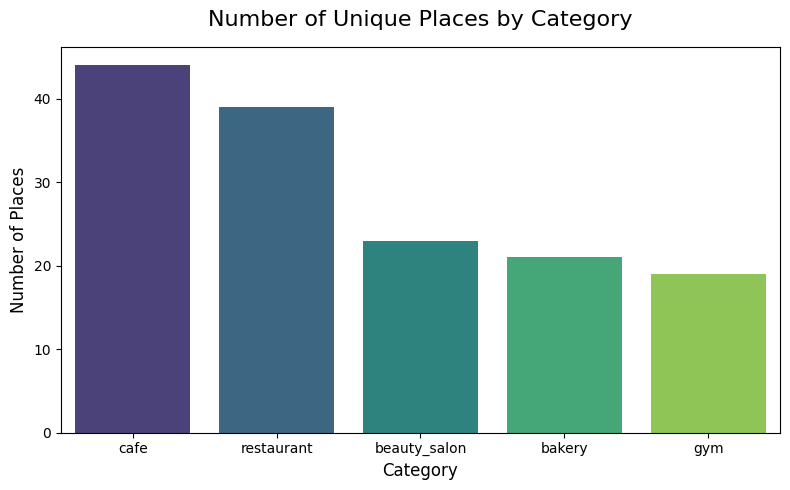

In [93]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=category_counts, 
    x='category',
    y='number_of_places',
    hue='category',
    palette='viridis', 
    legend=False
)

plt.title('Number of Unique Places by Category', fontsize=16, pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Places', fontsize=12)

plt.tight_layout()

plt.show()

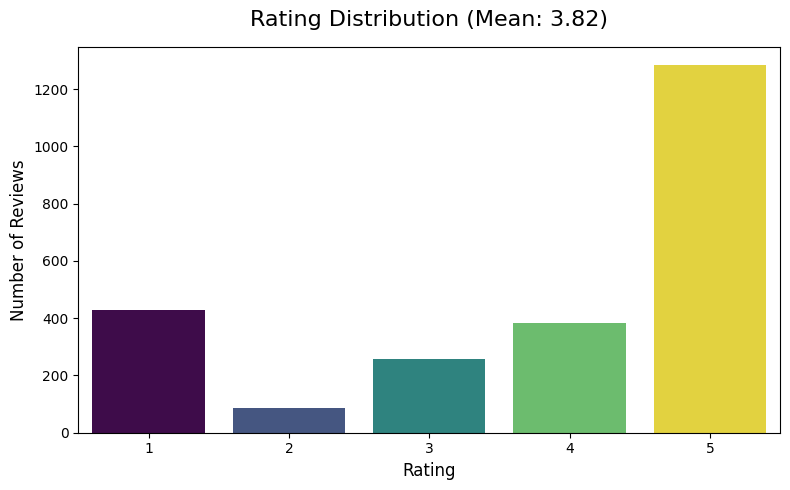

In [94]:
mean_rating = df['rating'].mean()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', hue='rating', palette='viridis', legend=False)
plt.title(f'Rating Distribution (Mean: {mean_rating:.2f})', fontsize=16, pad=15)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.tight_layout()
plt.show()

In [95]:
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['word_count'].describe()

count    2442.000000
mean       12.914005
std        19.829320
min         1.000000
25%         3.000000
50%         6.000000
75%        15.000000
max       410.000000
Name: word_count, dtype: float64

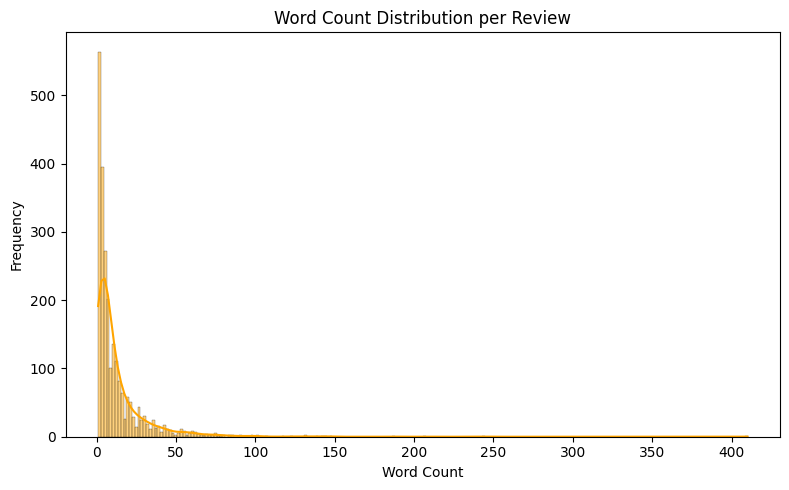

In [96]:

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='word_count', bins='auto', kde=True, color='orange')

plt.title('Word Count Distribution per Review')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [97]:
total_reviews = len(df)

short_reviews = df[df["word_count"] < 4]
short_reviews_percentage = (len(short_reviews) / total_reviews) * 100

print(f"Percentage of short reviews less than 4 words: {short_reviews_percentage:.2f}%")

Percentage of short reviews less than 4 words: 30.59%


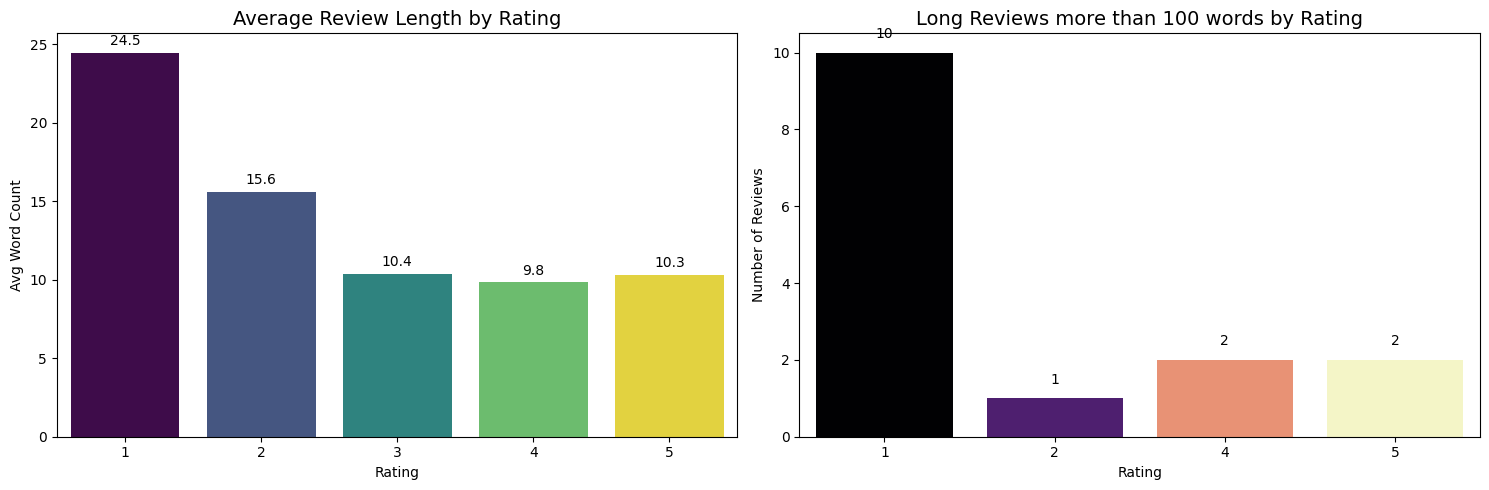

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.subplots_adjust(wspace=0.35)

# 1. Average review length by rating
avg_length_by_rating = (
    df.groupby('rating')['word_count']
    .mean()
    .reset_index(name='avg_word_count')
)

sns.barplot(
    data=avg_length_by_rating,
    x='rating',
    y='avg_word_count',
    hue='rating',
    palette='viridis',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Average Review Length by Rating', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Avg Word Count')
for bar, val in zip(axes[0].patches, avg_length_by_rating['avg_word_count']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}',
        ha='center', va='bottom', fontsize=10
    )

# 2. Distribution of long reviews (>100 words) by rating
long_reviews = df[df["word_count"] > 100]
long_dist = (
    long_reviews['rating']
    .value_counts()
    .sort_index()
    .reset_index()
)
long_dist.columns = ['rating', 'count']

sns.barplot(
    data=long_dist,
    x='rating',
    y='count',
    hue='rating',
    palette='magma',
    legend=False,
    ax=axes[1]
)
axes[1].set_title(f'Long Reviews more than 100 words by Rating', fontsize=14)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Number of Reviews')
for bar, val in zip(axes[1].patches, long_dist['count']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(val),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

Total unique users : 1906


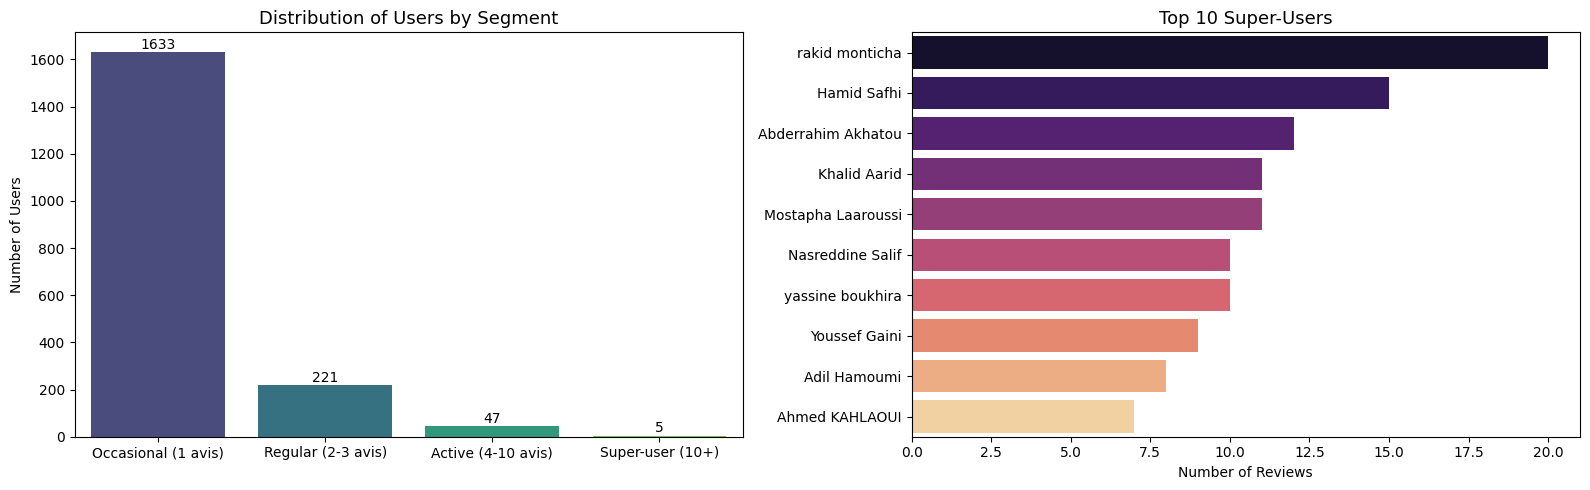

In [99]:
# Number of Reviews per User
user_activity = df.groupby('user_id').size().reset_index(name='nb_reviews')
print(f"Total unique users : {len(user_activity)}")

# User segmentation based on review count
def segment_user(review_count: int) -> str:
    if review_count == 1:
        return 'Occasional (1 avis)'
    elif review_count <= 3:
        return 'Regular (2-3 avis)'
    elif review_count <= 10:
        return 'Active (4-10 avis)'
    else:
        return 'Super-user (10+)'

user_activity['segment'] = user_activity['nb_reviews'].apply(segment_user)

# Distribution of users by segment
segment_counts = user_activity['segment'].value_counts().reset_index()
segment_counts.columns = ['segment', 'nb_users']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.subplots_adjust(wspace=0.35)

# Barplot segments
order = ['Occasional (1 avis)', 'Regular (2-3 avis)', 'Active (4-10 avis)', 'Super-user (10+)']
sns.barplot(
    data=segment_counts,
    x='segment', y='nb_users',
    hue='segment', palette='viridis',
    order=order, legend=False, ax=axes[0]
)
axes[0].set_title('Distribution of Users by Segment', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x')
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=10
    )

# Top 10 super-users
top_users = user_activity.nlargest(10, 'nb_reviews')
sns.barplot(
    data=top_users,
    x='nb_reviews', y='user_id',
    hue='user_id', palette='magma',
    legend=False, ax=axes[1]
)
axes[1].set_title('Top 10 Super-Users', fontsize=13)
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()



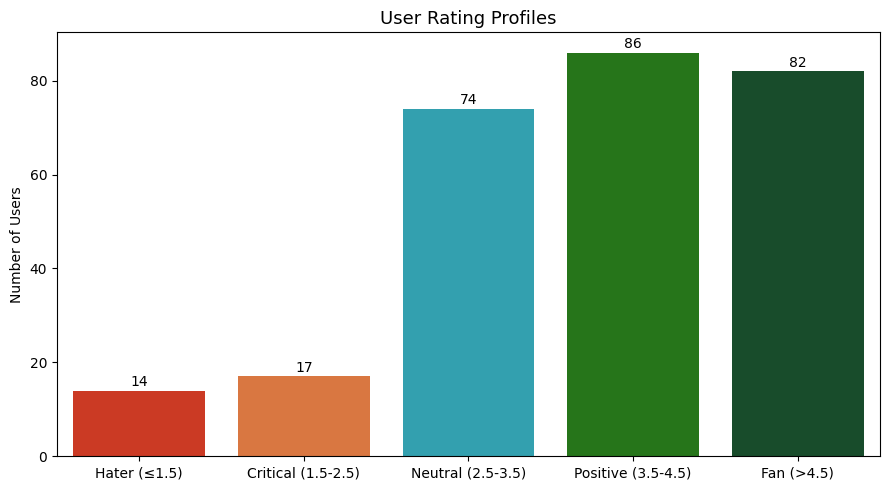

In [100]:
# Average rating per user (keep only those with at least 2 reviews)
user_ratings = (
    df.groupby('user_id')
    .agg(avg_rating=('rating', 'mean'), nb_reviews=('rating', 'count'))
    .reset_index()
)
user_ratings = user_ratings[user_ratings['nb_reviews'] >= 2]

# Classify user profiles based on average rating
def rating_profile(avg_rating: float) -> str:
    profiles = [
        (1.5, 'Hater (≤1.5)'),
        (2.5, 'Critical (1.5-2.5)'),
        (3.5, 'Neutral (2.5-3.5)'),
        (4.5, 'Positive (3.5-4.5)'),
    ]
    return next(
        (label for threshold, label in profiles if avg_rating <= threshold),
        'Fan (>4.5)'
    )

user_ratings['profile'] = user_ratings['avg_rating'].apply(rating_profile)

# Profile distribution
profile_order   = ['Hater (≤1.5)', 'Critical (1.5-2.5)', 'Neutral (2.5-3.5)', 'Positive (3.5-4.5)', 'Fan (>4.5)']
profile_palette = ["#1b840b", "#0F5529", "#1eb0c4", "#f26f28", "#e72608"]

profile_counts = user_ratings['profile'].value_counts().reset_index()
profile_counts.columns = ['profile', 'nb_users']

plt.figure(figsize=(9, 5))
sns.barplot(
    data=profile_counts,
    x='profile', y='nb_users',
    hue='profile',
    palette=profile_palette,
    order=profile_order,
    legend=False
)
plt.title('User Rating Profiles', fontsize=13)
plt.xlabel('')
plt.ylabel('Number of Users')


for bar in plt.gca().patches:
    if bar.get_height() > 0:
        plt.gca().text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10
        )

plt.tight_layout()
plt.show()

In [101]:
path = "../data/reference/moroccan_cities_regions.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

locations = set()

# Regions
for region in data["regions"]["data"]:
    for lang in ["en", "fr"]:
        name = region["names"].get(lang)
        if name:
            locations.add(normalize_text(name))

# Cities
for city in data["cities"]["data"]:
    for lang in ["en", "fr"]:
        name = city["names"].get(lang)
        if name:
            locations.add(normalize_text(name))

def remove_cities(text: str, locations: set) -> str:
    text = normalize_text(text)
    print(f"Before: {text}")

    words = text.split()
    filtered_words = [word for word in words if word not in locations]
    text = ' '.join(filtered_words)

    return text


In [102]:
path = "../data/reference/moroccan_cities_regions.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

locations = set()

# Regions
for region in data["regions"]["data"]:
    for lang in ["en", "fr"]:
        name = region["names"].get(lang)
        if name:
            locations.add(normalize_text(name))

# Cities
for city in data["cities"]["data"]:
    for lang in ["en", "fr"]:
        name = city["names"].get(lang)
        if name:
            locations.add(normalize_text(name))

sorted_locations = sorted(locations, key=len, reverse=True)

pattern = r'\b(?:' + '|'.join(map(re.escape, sorted_locations)) + r')\b'
location_regex = re.compile(pattern)

def text_cleanning(text: str) -> str:
    text = str(text).lower()

    # 0. Normalize first (important for matching)
    text = normalize_text(text)

    # 1. Remove locations (FAST)
    text = location_regex.sub(' ', text)

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 3. Remove phone numbers
    text = re.sub(r'\b\+?\d[\d\s\-\(\)]{7,}\d\b', ' ', text)

    # 4. Remove emojis
    text = emoji.replace_emoji(text, replace=' ')

    # 5. Replace punctuation
    text = text.translate(
        str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    )

    # 6. Token cleaning
    tokens = text.split()
    cleaned_tokens = []

    for token in tokens:
        token = re.sub(r'[^a-z\u00C0-\u017E\u0600-\u06FF0-9]', '', token)

        if not token:
            continue

        if re.search(r'[a-z\u00C0-\u017E\u0600-\u06FF]', token):
            cleaned_tokens.append(token)

    # Optional rule
    if "service" in cleaned_tokens and len(cleaned_tokens) > 1:
        cleaned_tokens.remove("service")

    text = ' '.join(cleaned_tokens)

    # 7. Normalize repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 8. Collapse spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [103]:
def load_dl_bundle(save_path: str) -> dict:
    model      = keras.models.load_model(f"{save_path}/model.keras")
    vectorizer = joblib.load(f"{save_path}/vectorizer.pkl")

    with open(f"{save_path}/meta.json", encoding="utf-8") as f:
        meta = json.load(f)

    print(f"   Bundle loaded from '{save_path}/'")
    print(f"   Classes   : {meta['classes']}")
    print(f"   Threshold : {meta['threshold']}")

    return {
        "model"     : model,
        "vectorizer": vectorizer,
        "classes"   : meta["classes"],
        "threshold" : meta["threshold"],
        "meta"      : meta,
    }

dl_bundle = load_dl_bundle("../models/language_identification_with_code_switching_and_noise")
dl_model = dl_bundle["model"]
dl_vectorizer = dl_bundle["vectorizer"]
dl_classes = dl_bundle["classes"]

   Bundle loaded from '../models/language_identification_with_code_switching_and_noise/'
   Classes   : ['arabizi', 'darija', 'english', 'french', 'msa']
   Threshold : 0.3


In [104]:
def predict_language_df(df, text_column, vectorizer, trained_model, classes_list, threshold=90.0):
    
    # 1. Clean text
    cleaned_sentences = df[text_column].astype(str).apply(text_cleanning)

    # 2. Vectorize
    X = vectorizer.transform(cleaned_sentences).toarray().astype(np.float32)

    # 3. Predict probabilities
    predictions = trained_model.predict(X, verbose=0)

    max_probs = predictions.max(axis=1)
    pred_indices = predictions.argmax(axis=1)

    predicted_labels = []
    
    for i in range(len(predictions)):
        prob = max_probs[i] * 100
        label = classes_list[pred_indices[i]]
        
        if prob >= threshold:
            predicted_labels.append(label)
        else:
            predicted_labels.append("unknown")

    # 6. Add column to dataframe
    df["lang"] = predicted_labels

    return df

In [105]:
df = predict_language_df(df, "text", dl_vectorizer, dl_model, dl_classes, threshold=90.0)

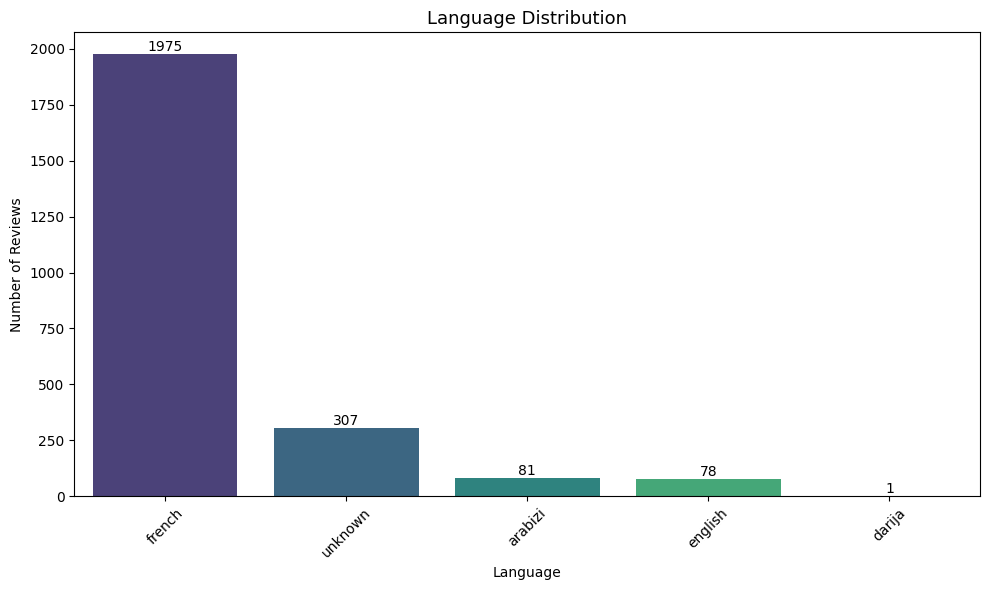

In [106]:

lang_counts = df['lang'].value_counts().reset_index()
lang_counts.columns = ['lang', 'count']

# Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=lang_counts,
    x='lang',
    y='count',
    hue='lang',
    palette='viridis',
    legend=False
)

plt.title('Language Distribution', fontsize=13)
plt.xlabel('Language')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [111]:
def balance_sentiment(path, samples_per_class=300):
    df = pd.read_csv(path)

    neg_df = df[df["rating"] <= 2]
    pos_df = df[df["rating"] >= 4]
    neutral_df = df[df["rating"] == 3]

    n = min(
        len(neg_df),
        len(pos_df),
        len(neutral_df),
        samples_per_class
    )

    neg = neg_df.sample(n=n, random_state=42)
    pos = pos_df.sample(n=n, random_state=42)
    neutral = neutral_df.sample(n=n, random_state=42)

    balanced_df = pd.concat([neg, pos, neutral]) \
        .sample(frac=1, random_state=42) \
        .reset_index(drop=True)

    return balanced_df

df_fr = balance_sentiment("../data/processed/french_reviews_world_wide.csv", samples_per_class=100)
df_en = balance_sentiment("../data/processed/english_reviews_world_wide.csv", samples_per_class=500)
df_ar = balance_sentiment("../data/processed/arabic_reviews_saudi.csv", samples_per_class=1000)
df_arabizi = pd.read_csv("../data/processed/arabizi_reviews_casa.csv")
df_darija = pd.read_csv("../data/processed/darija_reviews_casa.csv")


In [114]:
df["sentiment"] = "unknown"
df_combined = pd.concat([df[["user_id", "place_id", "text", "rating", "lang", "sentiment"]],df_ar, df_fr, df_en, df_arabizi, df_darija], ignore_index=True)

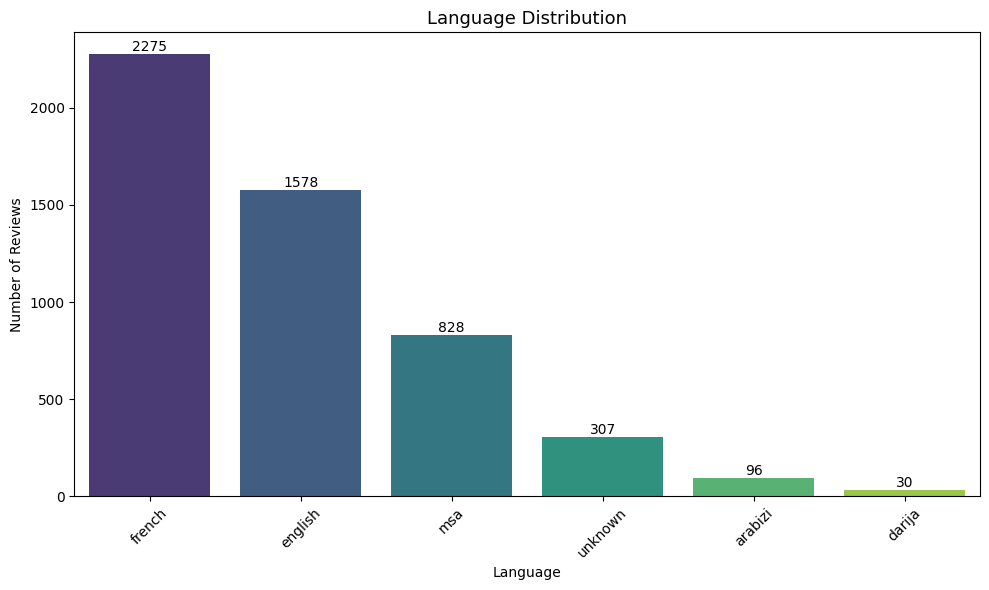

In [115]:

lang_counts = df_combined['lang'].value_counts().reset_index()
lang_counts.columns = ['lang', 'count']

# Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=lang_counts,
    x='lang',
    y='count',
    hue='lang',
    palette='viridis',
    legend=False
)

plt.title('Language Distribution', fontsize=13)
plt.xlabel('Language')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
df_combined.to_json(
    'reviews_data.json', 
    orient='records',
    force_ascii=False,
    indent=4
)